# How the robot's sensors fool statistics

The robot SCITOS G5 has **24 ultrasonic sensors** around its body. Each row is
one moment. The column `direction` is the move the robot made next.

Same idea as the class example "Catch the statistics that lie": a number can
look fine and still fool us. We will see it in 5 short steps.

1. Load the data
2. Sensors lie with the **mean** (skewed values)
3. **Bias** in the directions (one class is rare)
4. **Simpson's paradox** (a correlation that flips inside groups)
5. **Heatmap** + false correlations (too many tests = luck)

In [2]:
from IPython.display import Image
Image(url="https://www.researchgate.net/publication/338722213/figure/fig1/AS:881665106796544@1587216750237/SCITOS-G5-mobile-robot.jpg", width=400)

## 1. Load the data

The file has no header, so we give the columns our own names: 24 sensors and
the `direction`.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

cols = [f"sensor_{i}" for i in range(24)] + ["direction"]
df = pd.read_csv("sensor_readings_24.csv", header=None, names=cols)

print("rows:", df.shape[0], " columns:", df.shape[1])
df.head()

rows: 5456  columns: 25


,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,direction
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


## 2. Sensors lie with the mean

A sensor stops at **5.0** when the wall is too far ("I see nothing"). Many 5.0
values push the **mean** up. The **median** shows the real typical distance.

We look at `sensor_14`: mean, median, mode and std.

In [2]:
s = df["sensor_14"]
print("mean   :", round(s.mean(), 2))
print("median :", round(s.median(), 2))
print("mode   :", round(s.mode()[0], 2))
print("std    :", round(s.std(), 2))

mean   : 2.21
median : 1.33
mode   : 5.0
std    : 1.72


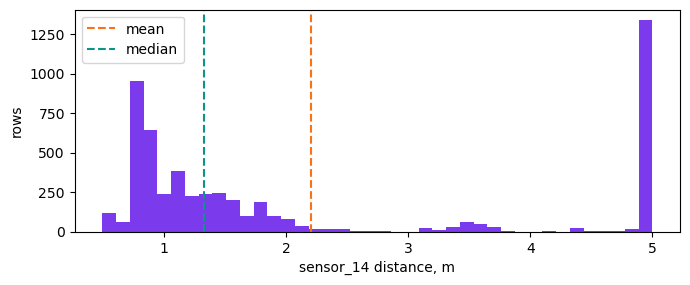

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(s, bins=40, color="#7C3AED")
ax.axvline(s.mean(), color="#F97316", linestyle="--", label="mean")
ax.axvline(s.median(), color="#0D9488", linestyle="--", label="median")
ax.set_xlabel("sensor_14 distance, m"); ax.set_ylabel("rows"); ax.legend()
plt.tight_layout(); plt.show()

The big bar at 5.0 is "no wall in range", not a real distance. It pulls the mean
to **2.21**, but the typical reading (median) is only **1.33**. The **mode is
5.0** — the most common value is the sensor being "blind". So the mean lies.

## 3. Bias in the directions

The moves are not balanced. `Move-Forward` and `Sharp-Right-Turn` are most of
the data, `Slight-Left-Turn` is rare, and `Sharp-Left-Turn` is missing. A model
trained here will prefer right turns.

In [4]:
counts = df["direction"].value_counts()
share = (counts / len(df) * 100).round(1)
pd.DataFrame({"count": counts, "share_%": share})

,count,share_%
direction,,
Move-Forward,2205,40.4
Sharp-Right-Turn,2097,38.4
Slight-Right-Turn,826,15.1
Slight-Left-Turn,328,6.0


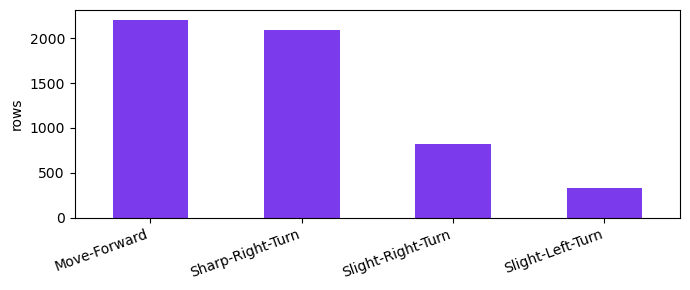

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
counts.plot(kind="bar", color="#7C3AED", ax=ax)
ax.set_ylabel("rows"); ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

## 4. Simpson's paradox

Two neighbour sensors, `sensor_6` and `sensor_7`, look positively linked over
all rows. But the link can change **inside** each direction group.

In [6]:
r = df["sensor_6"].corr(df["sensor_7"])
print("correlation over all rows: r =", round(r, 2))

correlation over all rows: r = 0.41


In [1]:
within = (df.groupby("direction")[["sensor_6", "sensor_7"]]
            .apply(lambda g: round(g.sensor_6.corr(g.sensor_7), 2))
            .rename("r inside the group"))
within

NameError: name 'df' is not defined

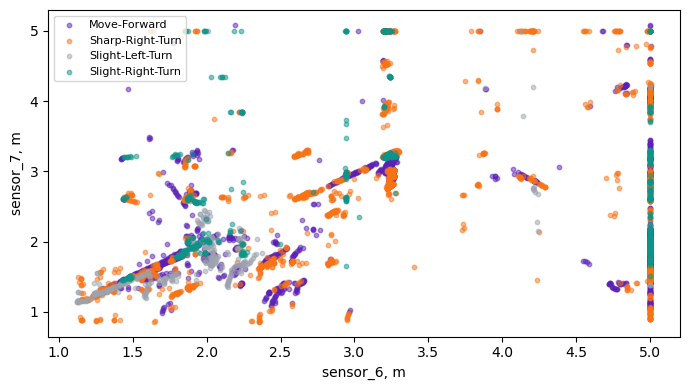

In [8]:
colors = {"Move-Forward": "#5B21B6", "Sharp-Right-Turn": "#F97316",
          "Slight-Right-Turn": "#0D9488", "Slight-Left-Turn": "#9CA3AF"}
fig, ax = plt.subplots(figsize=(7, 4))
for name, g in df.groupby("direction"):
    ax.scatter(g.sensor_6, g.sensor_7, s=10, alpha=0.5,
               color=colors[name], label=name)
ax.set_xlabel("sensor_6, m"); ax.set_ylabel("sensor_7, m")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Over all rows r = **+0.41**. But inside `Slight-Right-Turn` it turns **negative**
(r = **-0.16**). One number for everything hid this flip. Always ask: *inside
which group?*

## 5. Heatmap + false correlations

The heatmap shows how the 24 sensors relate. Neighbour sensors look the same
way, so they are warm (high correlation); far sensors are cool.

Then a warning: if we test **many** pairs, some look "significant" only by luck.

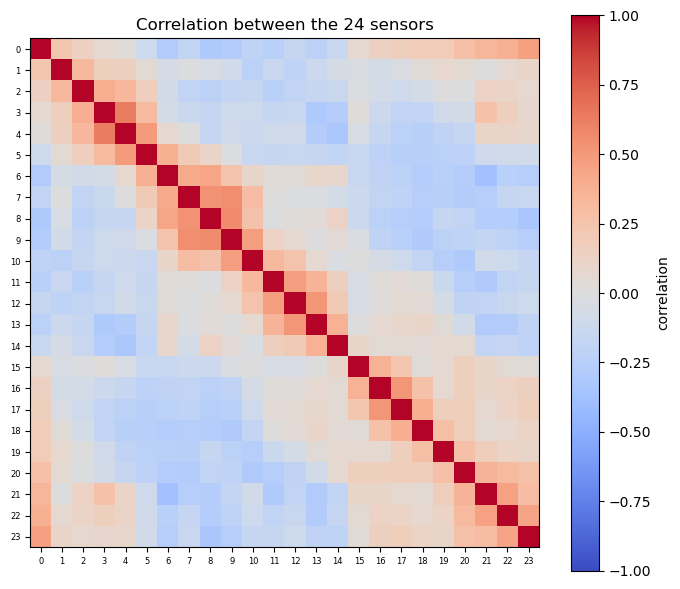

In [9]:
corr = df.filter(like="sensor_").corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(24)); ax.set_yticks(range(24))
ax.set_xticklabels(range(24), fontsize=6)
ax.set_yticklabels(range(24), fontsize=6)
ax.set_title("Correlation between the 24 sensors")
fig.colorbar(im, label="correlation")
plt.tight_layout(); plt.show()

In [10]:
# 8 columns of PURE random noise -> 28 pairs. Some cross p < 0.05 just by luck.
rng = np.random.default_rng(0)
noise = pd.DataFrame({f"noise{i}": rng.standard_normal(len(df))
                      for i in range(8)})

hits = 0
for i in range(8):
    for j in range(i + 1, 8):
        r, p = stats.pearsonr(noise[f"noise{i}"], noise[f"noise{j}"])
        if p < 0.05:
            print(f"noise{i} vs noise{j}:  r={r:.3f}  p={p:.3f}  <- 'significant', but pure noise")
            hits += 1
print("false 'significant' pairs:", hits, "of 28")

noise1 vs noise5:  r=-0.034  p=0.013  <- 'significant', but pure noise
false 'significant' pairs: 1 of 28


These columns are 100% random, yet a pair still crosses `p < 0.05`. With more
tests you always find fake "discoveries". A small p-value is **not** proof.

**Summary:** the mean can lie (use the median), the classes are not balanced, a
correlation can flip inside groups, and too many tests create luck. Always check
where a number comes from.